This is a quick project, using ViTs which I studied recently, from the An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale, in Proceedings of the International Conference on Learning Representations (ICLR) paper. Below is an implementation of ViT using Google's "google/vit-base-patch16-224" model, available on Hugging Face, trained to identify benign and malignant tumomrs from MRIs of brain. The dataset was available on Kaggle.

In [10]:
# Some metadata 

import torch
import sys
import platform
import transformers as t

print(f'------\n'
    f'Python version: {sys.version} \n'
      f'System: {platform.system()} \n'
      f'Platform: {platform.platform()}')

print(f'------\n'
      f'PyTorch version: {torch.__version__}\n'
      f'CUDA available: {torch.cuda.is_available()}\n'
      f'CUDA device count: {torch.cuda.device_count()}\n')

print(f'-------\n'
      f'Transformers version: {t.__version__}\n'
      f'-------\n')

------
Python version: 3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)] 
System: Windows 
Platform: Windows-11-10.0.26100-SP0
------
PyTorch version: 2.5.1+cu124
CUDA available: True
CUDA device count: 1

-------
Transformers version: 4.48.1
-------



In [11]:
# Start by loading the dataset

from datasets import load_dataset

dataset = load_dataset("imagefolder", 
                       data_dir=r"C:\Machine Learning\Datasets\Brain Tumor MRI Dataset",
                       split=None
                       )
dataset

Resolving data files:   0%|          | 0/7023 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7023
    })
})

In [12]:
# Print out the keys of the dataset (splits)
print("Available splits:", list(dataset.keys()))

# For each split, print the number of samples and column names
for split, ds in dataset.items():
    print(f"\nSplit: {split}")
    print("Number of samples:", len(ds))
    print("Columns:", ds.column_names)


Available splits: ['train']

Split: train
Number of samples: 7023
Columns: ['image', 'label']


In [18]:
dataset['train'].features['label'].names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [20]:
dataset['train'].features['label']

ClassLabel(names=['glioma', 'meningioma', 'notumor', 'pituitary'], id=None)

In [27]:
# Plot class distribuition

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

labelnames = dataset['train'].features['label'].names
labelidx = [sample['label'] for sample in dataset['train']]
labelcounts = Counter(labelidx)
for i, count in labelcounts.items():
    print(f'{labelnames[i]}: {count}')

glioma: 1621
meningioma: 1645
notumor: 2000
pituitary: 1757


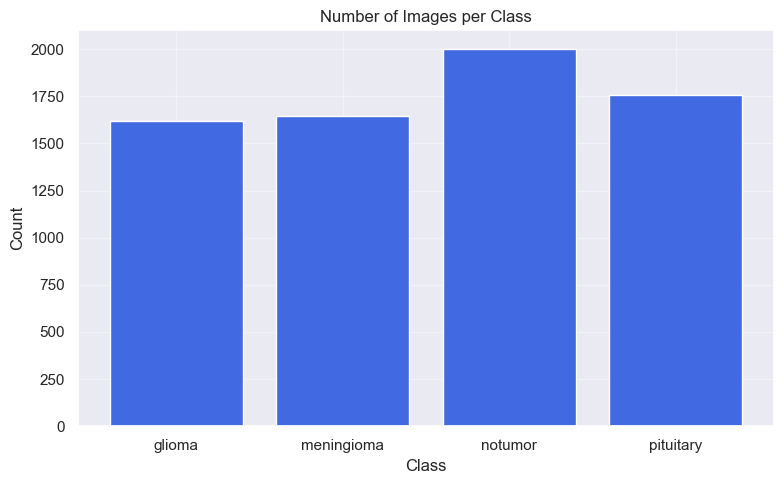

In [29]:
class_counts = [labelcounts[i] for i in range(len(labelnames))]

import seaborn as sns
sns.set_theme()
plt.figure(figsize=(8, 5))
plt.bar(labelnames, class_counts, color="royalblue")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Fortunately, the class imbalance is quite low, so we won't need any additional pre-processing here. Let's generate a train-test split, then we'll plot some sample images.

In [31]:
# Generate a train-test split

split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset['train']
eval_dataset = split_dataset['test']

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['image', 'label'],
    num_rows: 5618
})
Dataset({
    features: ['image', 'label'],
    num_rows: 1405
})


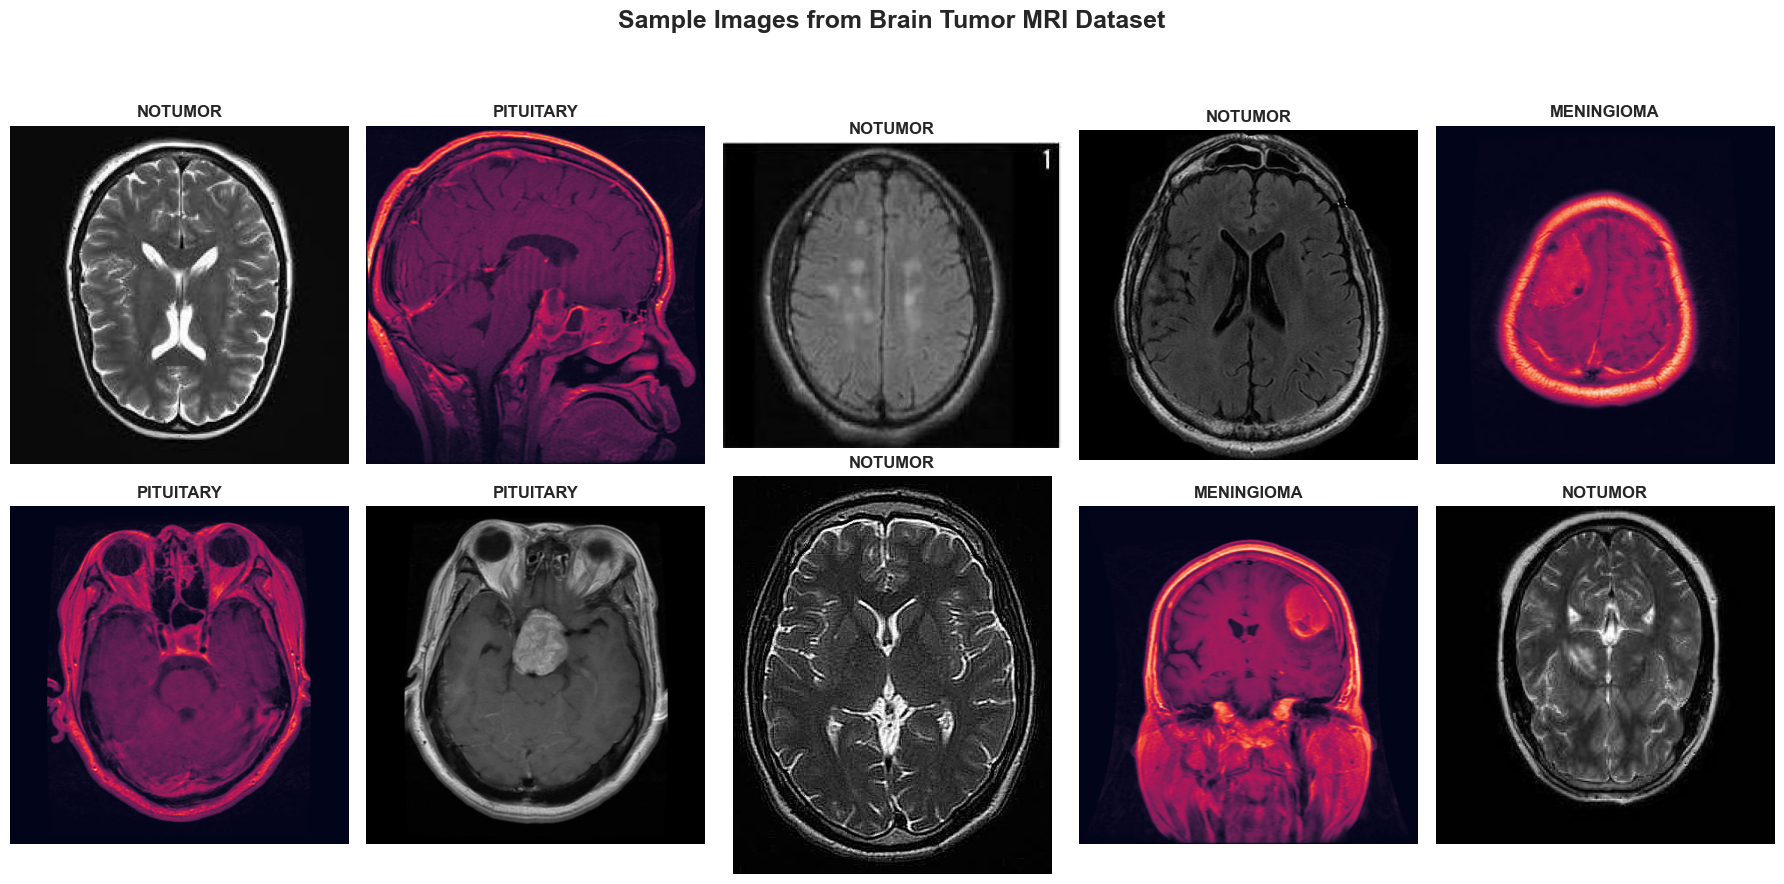

In [40]:
import matplotlib.pyplot as plt
import random

# Automatically get label names
label_names = train_dataset.features['label'].names

# Number of images to display
num_images = 10
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(18, 9))
fig.suptitle("Sample Images from Brain Tumor MRI Dataset", fontsize=18, weight='bold')

# Select random samples for diversity
indices = random.sample(range(len(train_dataset)), num_images)

for ax, idx in zip(axes.flatten(), indices):
    image = train_dataset[idx]['image']
    label = train_dataset[idx]['label']
    label_name = label_names[label]

    ax.imshow(image)
    ax.set_title(label_name.upper(), fontsize=12, weight="bold")
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
plt.show()


Before continuing, a word for each type of tumor:

1. Pituitary: A mostly benign tumor, characterized by an abnormal growth of tissue in the pituitary gland, a pea-sized organ in the brain that controls hormones. They are often diagnosed through imaging studies like MRI or CT scans. 

2. Glioma: A glioma is a type of brain or spinal cord tumor that originates from glial cells, the supporting cells of the brain and spinal cord. Gliomas are the most common type of primary brain tumor and can be either low-grade (slow-growing) or high-grade (fast-growing). They are typically cancerous, but some can be benign (non-cancerous). 

3. Meningioma: A meningioma is a tumor that originates from the "meninges," the protective layers of tissue surrounding the brain and spinal cord. While most meningiomas are benign, some can be malignant and require treatment. Meningiomas are the most common type of primary brain tumor, meaning they originate in the brain rather than spreading from elsewhere in the body. 

4. "Notumor": No tumors, thank heavens.

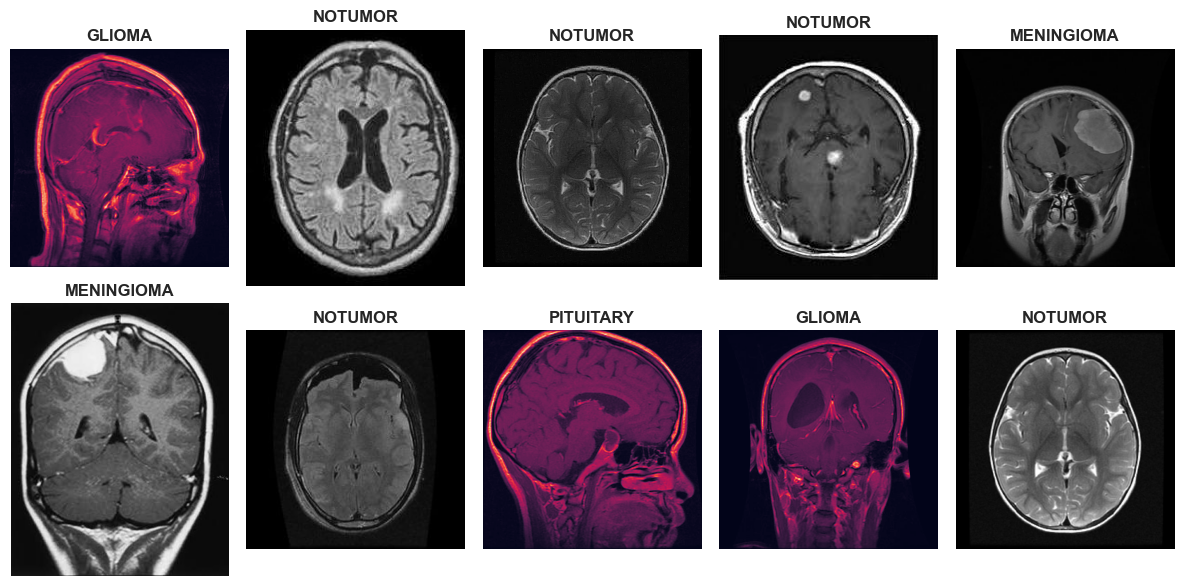

In [42]:
import matplotlib.pyplot as plt

# Define label names
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
fig, axes = plt.subplots(2, 5, figsize=(12, 6))  # Adjust size for better spacing

for i, ax in enumerate(axes.flatten()):
    image = train_dataset['image'][i]  # Get image
    label = train_dataset['label'][i]  # Get label index

    ax.imshow(image)
    ax.set_title(labels[label].upper(), fontsize=12, weight="bold")  # Map index to label name
    ax.axis('off')  # Hide axes

plt.tight_layout()
plt.show()


One more visualization, as the original didn't show any glioma tumors.

In [43]:
print(f'Labels: {dataset["train"].features["label"].names} \nTotal: 4')

Labels: ['glioma', 'meningioma', 'notumor', 'pituitary'] 
Total: 4


In [44]:
from transformers import ViTImageProcessor

# Load the processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

# Define preprocessing function
def preprocess(batch):
    images = [image.convert("RGB") for image in batch['image']]  # Convert all images to RGB
    processed = processor(images, return_tensors="pt")  # Process images
    batch['pixel_values'] = processed['pixel_values']  # Store only pixel values
    return batch

# Apply preprocessing
train_dataset = train_dataset.map(preprocess, batched=True)
eval_dataset = eval_dataset.map(preprocess, batched=True)

# Set dataset format for PyTorch training
train_dataset.set_format("torch", columns=["pixel_values", "label"])
eval_dataset.set_format("torch", columns=["pixel_values", "label"])


In [45]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(model_name, num_labels=len(train_dataset.features['label'].names),
                                                  ignore_mismatched_sizes=True)

model.config.id2label = {i: name for i, name in enumerate(train_dataset.features['label'].names)}
model.config.label2id = {name: i for i, name in enumerate(train_dataset.features['label'].names)}


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [48]:
from transformers import TrainingArguments
from transformers import DefaultDataCollator

training_args = TrainingArguments(
    output_dir='./vit-brain-mri-tumor',
    per_device_eval_batch_size=16,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.0001,
    num_train_epochs=3,
    logging_steps=10,
    save_strategy='epoch',
    eval_strategy='epoch',
    load_best_model_at_end=True  
)

data_collator = DefaultDataCollator()

In [49]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, predictions)
    }

In [50]:
from transformers import Trainer

trainer = Trainer(
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    model=model
    )

In [51]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.095800,0.081868,0.970819
2,0.005900,0.043731,0.983630
3,0.003500,0.038892,0.985053


TrainOutput(global_step=1056, training_loss=0.09586832481418793, metrics={'train_runtime': 699.3209, 'train_samples_per_second': 24.101, 'train_steps_per_second': 1.51, 'total_flos': 1.3060734043902935e+18, 'train_loss': 0.09586832481418793, 'epoch': 3.0})

In [52]:
trainer.save_model("vit-braintumor-mri")  # Save model
processor.save_pretrained("vit-braintumor-mri")  # Save processor (ViTImageProcessor)

['vit-braintumor-mri\\preprocessor_config.json']